In [1]:
import os
import time
# 切换工作目录到COMPASS项目主目录
os.chdir(os.path.abspath(os.path.join(os.getcwd(), "../..")))

In [2]:
import compass_env
import gymnasium as gym
env = gym.make("compass-highway-v2", render_mode="rgb_array", verbose=False, config={
    "case_num": 1
})
obs, info = env.reset(seed=2)



找到 168 个.state.xml.gz文件


In [ ]:

import imageio
import numpy as np

render_path = "compass_env/output/"
save_dir = "assets/gif/"
case_name = "case1-seed-2"
env.unwrapped.config["gui"]["cache_img_name"] = render_path + case_name + ".png"

for _ in range(150):
    env.render()
    env.step([0,0])
    time.sleep(0.05)




d:\Anaconda\envs\graphflow\lib\site-packages\gymnasium\utils\passive_env_checker.py:334: UserWarning: WARN: No render fps was declared in the environment (env.metadata['render_fps'] is None or not defined), rendering may occur at inconsistent fps.
  logger.warn(
d:\Anaconda\envs\graphflow\lib\site-packages\gymnasium\utils\passive_env_checker.py:270: UserWarning: WARN: RGB-array rendering should return a numpy array, got <class 'NoneType'>
  logger.warn(
D:\Temp\ipykernel_31156\2880582210.py:21: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(os.path.join(render_path, filename))


In [ ]:
for _ in range(120):
    obs, rewards, terminated, truncated, infos = env.step([0,0])


In [ ]:
import traci
import traci.constants as tc
traci.simulation.saveState("./compass_env/output/test.state.xml.gz")
saved_step = env.unwrapped.steps
saved_time = env.unwrapped.time
saved_time_bias = env.unwrapped.time_bias

In [ ]:
traci.simulation.loadState("./compass_env/output/test.state.xml.gz")
env.unwrapped.time = saved_time
env.unwrapped.steps = saved_step
ego_id = env.unwrapped.config["egoID"]
traci.vehicle.subscribe(ego_id, env.unwrapped.veh_state_vars)
traci.vehicle.subscribeContext(
    ego_id,
    tc.CMD_GET_VEHICLE_VARIABLE,
    env.unwrapped.config["observation"]["obs_radius"],
    varIDs=env.unwrapped.veh_state_vars,
)
if env.unwrapped.render_mode == "human":
    ViewID = env.unwrapped.config["gui"]["view"]
    traci.simulation.getTime()
    traci.gui.setSchema(ViewID, env.unwrapped.config["gui"]["schema"])
    traci.gui.setZoom(ViewID, env.unwrapped.config["gui"]["zoom"])
    traci.gui.trackVehicle(ViewID, ego_id)


In [ ]:
obs, rewards, terminated, truncated, infos = env.step([0,0])

In [ ]:
from compass_env.envs.compass_highway_env import CompassHighwayEnv
import traci 
import time
import numpy as np
import math
from traci import constants as tc
from compass_env.utils import NeighborHistoryObs, vis_matrix

env = CompassHighwayEnv(render_mode = 'human', config={
    "case_num": -1
},verbose=True)
obs, info = env.reset()


data\test_cases\no18_2500_merge_5.sumocfg
front / back TTC  : 27.38 / -100.00 s
lf / lr TTC       : 100.00 / 100.00 s
rf / rr TTC       : 100.00 / 100.00 s
leader            :  ('flow_merge.26', 19.35541431557658)
follower          :  ('flow_merge.27', 19.436344888379267)
left leaders      :  ()
left followers    :  ()
right leaders     :  ()
right followers   :  ()
could LC left     :  False
could LC right    :  False
LC state L        :  ()
LC state R        :  ()
LC state          :  ●●●●●●●●●●●●●●●●●
can_reach_multi   :  ●●●○●●●
speed / speedlim  : 31.92 / 39.68 km/h
laneID / edgeID   :  761727435#1_0 , 761727435#1
lanePos / remDist : 0.00 / 1074.38 m


d:\Anaconda\envs\graphflow\lib\site-packages\stable_baselines3\common\env_checker.py:67: UserWarning: It seems that your observation veh is an image but its `dtype` is (float32) whereas it has to be `np.uint8`. If your observation is not an image, we recommend you to flatten the observation to have only a 1D vector
  warnings.warn(
d:\Anaconda\envs\graphflow\lib\site-packages\stable_baselines3\common\env_checker.py:75: UserWarning: It seems that your observation space veh is an image but the upper and lower bounds are not in [0, 255]. Because the CNN policy normalize automatically the observation you may encounter issue if the values are not in that range.
  warnings.warn(
d:\Anaconda\envs\graphflow\lib\site-packages\stable_baselines3\common\env_checker.py:88: UserWarning: The minimal resolution for an image is 36x36 for the default `CnnPolicy`. You might need to use a custom features extractor cf. https://stable-baselines3.readthedocs.io/en/master/guide/custom_policy.html
  warnings.w

data\test_cases\no6_4000_merge_2.sumocfg
front / back TTC  : -100.00 / 100.00 s
lf / lr TTC       : -100.00 / 100.00 s
rf / rr TTC       : 64.78 / 100.00 s
leader            :  ('flow_merge.30', 161.73170727365226)
follower          :  ('', -1.0)
left leaders      :  (('flow_merge.32', 61.060909683732945), ('flow_merge.33', 36.98331744490339), ('flow_merge.32', 61.060909683732945))
left followers    :  ()
right leaders     :  ()
right followers   :  ()
could LC left     :  True
could LC right    :  False
LC state L        :  ('stay', 'sublane')
LC state R        :  ()
LC state          :  ●●●●●●●●○●●●●○●●●
can_reach_multi   :  ●●○○●●●
speed / speedlim  : 36.87 / 39.50 km/h
laneID / edgeID   :  216048993_0 , 216048993
lanePos / remDist : 0.00 / 663.35 m
front / back TTC  : 60.37 / 100.00 s
lf / lr TTC       : 100.00 / 100.00 s
rf / rr TTC       : 60.37 / 100.00 s
leader            :  ('flow_merge.30', 161.16795840543105)
follower          :  ('', -1.0)
left leaders      :  (('flow_merge

front / back TTC  : -6.14 / -100.00 s
lf / lr TTC       : 11.39 / 3.59 s
rf / rr TTC       : 72.72 / -3.61 s
leader            :  ('flow_main.49', 52.147737483798096)
follower          :  ('flow_exit.34', 54.6339977231097)
left leaders      :  (('flow_exit.33', 37.01480180929639), ('flow_main.47', 165.67678213070167))
left followers    :  (('flow_exit.39', 383.9553323122759), ('flow_main.48', 12.253967446907382))
right leaders     :  ()
right followers   :  (('flow_main.51', 7.791770531577981), ('flow_main.57', 450.7295234366479))
could LC left     :  True
could LC right    :  True
LC state L        :  ('stay', 'strategic')
LC state R        :  ('stay', 'strategic')
LC state          :  ●●●●●●●●○○○●●●●●●
can_reach_multi   :  ●○○○●●●
speed / speedlim  : 68.24 / 80.43 km/h
laneID / edgeID   :  96615334#0_1 , 96615334#0
lanePos / remDist : 0.00 / 1378.37 m

=============== Reward Details Table ===============
|----------------------|---------------------------|
| Reward Name          |   

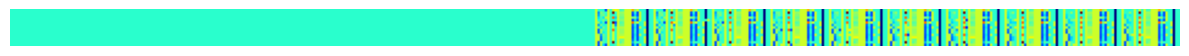

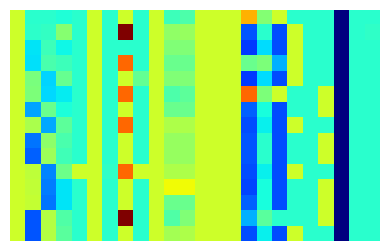

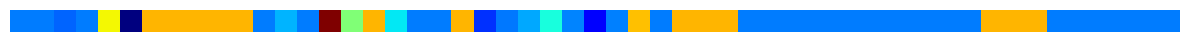

In [ ]:
obs, reward, terminated, truncated, info = env.step(action=[0,0])
nobs = obs['veh']
vis_matrix(nobs.reshape(nobs.shape[0], -1),cmap='jet',figure_size=(12, 8))
vis_matrix(nobs[:,-1,:],cmap='jet',figure_size=(4, 4))
vis_matrix(obs['ego'].reshape(1, -1),cmap='jet',figure_size=(12, 1))


In [ ]:
tic = time.time()
done = False
while not done:
    # action = env.action_space.sample()
    action = [0,0]
    obs, reward, terminated, truncated, info = env.step(action=action)
    done = terminated or truncated
toc = time.time()
print(toc - tic)


front / back TTC  : -1.18 / 23.39 s
lf / lr TTC       : -10.36 / 2.84 s
rf / rr TTC       : -16.88 / 12.67 s
leader            :  ('flow_main.28', 11.370650350113408)
follower          :  ('flow_main.33', 224.70768779199176)
left leaders      :  (('flow_merge.40', 146.95365471015276), ('flow_main.30', 467.6842564244377), ('flow_merge.36', 257.1795897260251))
left followers    :  (('flow_main.41', 1354.875199285942), ('flow_merge.42', 330.2396913425636), ('flow_main.32', 14.730498067659482), ('flow_merge.42', 330.2396913425636))
right leaders     :  (('flow_main.20', 558.1360610750162), ('flow_main.21', 418.5034229104387), ('flow_merge.38', 206.71287871776252))
right followers   :  (('flow_merge.65', 1209.0448677291768), ('flow_main.31', 95.85146025744041), ('flow_merge.46', 457.9802051168485))
could LC left     :  False
could LC right    :  False
LC state L        :  ('left', 'speedGain', 'TraCI')
LC state R        :  ()
LC state          :  ●●●●●●○●●●●○●●○●●
can_reach_multi   :  ●●○○○

In [ ]:
obs, info = env.reset()

data\test_cases\no25_1500_pass_7.sumocfg
{'flow_exit.15': {66: (58174.757816487705, 88456.4292841931), 64: 33.2275921779871, 67: 127.6934541579706, 114: 0.8497612743638499, 80: '761727441#2', 81: '761727441#2_0', 82: 0, 86: 10734.994113179375, 184: 0.0, 68: 5.2, 77: 2.0, 79: 'car_suv', 73: 'private', 91: 0, 183: 33.33}, 'flow_exit.16': {66: (58045.16491441293, 88556.5664135671), 64: 41.713260826307774, 67: 127.69345415803069, 114: 0.5315969532355638, 80: '761727441#2', 81: '761727441#2_0', 82: 0, 86: 10571.223478262127, 184: 0.0, 68: 4.8, 77: 1.9, 79: 'car_sport', 73: 'private', 91: 0, 183: 41.810344}, 'flow_exit.17': {66: (57700.34984382162, 88827.30346554994), 64: 28.92497475089505, 67: 129.6737032494716, 114: 1.5435807689093046, 80: '761727441#2', 81: '761727441#2_1', 82: 1, 86: 10132.129663396347, 184: 0.20000000000000018, 68: 5.2, 77: 2.0, 79: 'car_suv', 73: 'private', 91: 1, 183: 33.33}, 'flow_main.30': {66: (58183.100274044504, 88454.02422625819), 64: 30.43446251682006, 67: 127.

In [ ]:
traci.vehicle.changeLaneRelative('t_0', 1, 4.0)

In [ ]:

obs, reward, terminated, truncated, info = env.step([0, 0])


can_reach_multi   :  ●●○○○●●
front / back TTC  : -3.63 / 100.00 s
speed / speedlim  : 40.74 / 78.74 km/h
laneID / edgeID   :  96615334#0_2 , 96615334#0
lanePos / remDist : 116.04 / 1262.33 m
leader            :  ('flow_exit.113', 13.216794732488452)
follower          :  ('', -1.0)
left leaders      :  (('flow_exit.113', 13.216794732488452), ('flow_exit.109', 161.92682375494695), ('flow_exit.108', 248.27612539173361), ('flow_main.95', 332.66592186564566))
left followers    :  (('flow_exit.114', 2.5585213058735263),)
right leaders     :  (('flow_main.104', 134.0091925351689), ('flow_main.106', 29.171252845876168))
right followers   :  ()
could LC left     :  True
could LC right    :  True
LC state L        :  (('right', 'sublane'), ('right', 'sublane'))
LC state R        :  (('stay', 'strategic'), ('stay', 'strategic'))
LC state          :  ●●●●●●●○○○○●●○●●●
{'flow_exit.102': {66: (393.31378214541115, 128042.86426416741), 64: 6.740159067383743, 70: 2.0, 67: 122.17576671708501, 114: -0.54

In [ ]:

env.close()

In [ ]:
from stable_baselines3.common.env_checker import check_env


# It will check your custom environment and output additional warnings if needed
check_env(env)

data\test_cases\no6_4000_merge_2.sumocfg
front / back TTC  : 62.67 / 100.00 s
lf / lr TTC       : 37.78 / 100.00 s
rf / rr TTC       : 62.67 / 100.00 s
leader            :  ('flow_merge.32', 80.74687091611221)
follower          :  ('', -1.0)
left leaders      :  (('flow_merge.33', 28.345498177656026),)
left followers    :  ()
right leaders     :  ()
right followers   :  ()
could LC left     :  True
could LC right    :  False
LC state L        :  ('stay', 'sublane')
LC state R        :  ()
LC state          :  ●●●●●●●●○●●●●○●●●
can_reach_multi   :  ●●○○●●●
speed / speedlim  : 38.11 / 39.68 km/h
laneID / edgeID   :  216048993_0 , 216048993
lanePos / remDist : 0.00 / 663.35 m
data\test_cases\no17_2500_pass_5.sumocfg
front / back TTC  : -75.51 / 63.08 s
lf / lr TTC       : -100.00 / -74.35 s
rf / rr TTC       : 100.00 / 100.00 s
leader            :  ('flow_exit.26', 76.48730798724318)
follower          :  ('flow_exit.27', 21.728503815336808)
left leaders      :  (('flow_exit.25', 238.31059

In [ ]:
traci.vehicle.setLaneChangeMode('t_0', 0b0000000000000000)